# Part 2 (v2) — Hinglish Retrieval Baselines, with the fixes from the first run

**What the first run showed:** dense >> hybrid; Hinglish loses ranking quality; Hinglish queries always land on English passages; Hit@5 is saturated; latency numbers were noisy.

**What v2 adds**
1. **Hindi-only gold** (`hi_only`) next to the combined gold (`all`). This isolates the cross-script problem: can a Roman query reach the Devanagari evidence?
2. **BM25 with stopwords removed** (the raw version stays as an ablation) and a **fine alpha grid** between 0.8 and 1.0
3. **Median latency** over repeated runs
4. **Dev/test split by group** (tune on dev, report on test) and **bootstrap confidence intervals**
5. **Multi-query hook:** a transform returns a *list* of queries, and rankings are fused with RRF. Part 3 and your transliteration / lexicon experiments plug in here
6. **Controlled Hinglish variants** (one change at a time) so spelling effects are separable

Passages and cached embeddings from v1 are reused. New queries go to `data/queries_v2.csv`, so the old file is untouched.

In [1]:
# 0. Install dependencies (once per runtime)
%pip install -q rank-bm25 sentence-transformers wikipedia-api pandas matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.8/129.8 kB 5.3 MB/s eta 0:00:00


In [2]:
# 1. Imports and configuration
import os, re, json, time, random
import numpy as np
import pandas as pd

DATA_DIR, RESULTS_DIR = "data", "results"
os.makedirs(DATA_DIR, exist_ok=True); os.makedirs(RESULTS_DIR, exist_ok=True)

PASSAGES_FILE = f"{DATA_DIR}/passages.jsonl"       # reused from v1
QUERIES_FILE  = f"{DATA_DIR}/queries_v2.csv"       # new file; v1 queries.csv is not touched

REBUILD_CORPUS = False
MODEL_NAME = "BAAI/bge-m3"          # lighter: "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
MAX_SEQ_LEN = 512

KS = (1, 3, 5, 10)
CANDIDATE_DEPTH = 100
RRF_K = 60
ALPHA_DEFAULT = 0.5
N_REPEATS = 3                       # latency = median over this many repeats per query
DEV_FRACTION = 0.5                  # share of GROUPS used for tuning (alpha); the rest is test
N_BOOT = 1000
SEED = 42
random.seed(SEED); np.random.seed(SEED)

STATES = {
    "Rajasthan": "Rajasthan", "Maharashtra": "Maharashtra", "Gujarat": "Gujarat", "Kerala": "Kerala",
    "Bihar": "Bihar", "Uttar Pradesh": "Uttar Pradesh", "Tamil Nadu": "Tamil Nadu",
    "West Bengal": "West Bengal", "Karnataka": "Karnataka", "Punjab": "Punjab, India",
    "Madhya Pradesh": "Madhya Pradesh", "Odisha": "Odisha",
}
CHUNK_WORDS, CHUNK_OVERLAP, MAX_CHUNKS_PER_ARTICLE = 120, 20, 15

# Function words removed for the stopword-BM25 variant (English, Devanagari Hindi, Romanized Hindi)
STOPWORDS = set("""
what is the of in a an and to for which who where when how are was were by on at with from it its this that
का की के है हैं में से को और पर यह वह था थी थे क्या कौन कब कहाँ कहां कैसे कि भी तो
ka ki ke hai hain mein me se ko aur par yeh ye woh wo tha thi the kya kaun kab kahan kaha kaise he ki bhi toh
""".split())
print("Config loaded.")

Config loaded.


## 2. Corpus (reused from v1 if `data/passages.jsonl` exists)

In [3]:
def clean_wiki_text(text):
    text = re.sub(r"={2,}", " ", text)
    return re.sub(r"\s+", " ", text).strip()

def chunk_text(text, size=CHUNK_WORDS, overlap=CHUNK_OVERLAP, max_chunks=MAX_CHUNKS_PER_ARTICLE):
    words = text.split(); step = size - overlap; chunks = []
    for start in range(0, len(words), step):
        piece = words[start:start + size]
        if len(piece) < 30: break
        chunks.append(" ".join(piece))
        if len(chunks) >= max_chunks: break
    return chunks

def build_corpus():
    import wikipediaapi
    en = wikipediaapi.Wikipedia(user_agent="HinglishRAGResearch/1.0", language="en")
    records = []
    for state, title in STATES.items():
        en_page = en.page(title)
        if not en_page.exists():
            print(f"  [skip] {title}"); continue
        hi_page = en_page.langlinks.get("hi")
        for lang, page in (("en", en_page), ("hi", hi_page)):
            if page is None:
                print(f"  [warn] no Hindi page for {state}"); continue
            for i, ch in enumerate(chunk_text(clean_wiki_text(page.text))):
                records.append({"pid": f"{state}|{lang}|{i}", "state": state, "lang": lang, "text": ch})
    with open(PASSAGES_FILE, "w", encoding="utf-8") as f:
        for r in records: f.write(json.dumps(r, ensure_ascii=False) + "\n")
    print(f"Saved {len(records)} passages")

if REBUILD_CORPUS or not os.path.exists(PASSAGES_FILE):
    build_corpus()
passages = pd.read_json(PASSAGES_FILE, lines=True, encoding="utf-8")
print(passages.groupby("lang").size().to_string())
PID_TO_LANG = dict(zip(passages.pid, passages.lang))

Saved 344 passages
lang
en    180
hi    164


## 3. Queries, gold labels, dev/test split
`data/queries_v2.csv` columns: `qid, group_id, lang_type, variant, state, query, answer_en, answer_hi`

The seed file uses **controlled Hinglish variants**, each changing one thing from the base spelling:

| variant | change |
|---|---|
| `base` | standard Roman spelling |
| `vowel2x` | doubled vowels (rajdhani -> raajdhaani) |
| `lower` | all lowercase (breaks the capitalized state name) |
| `he_for_hai` | colloquial "he" instead of "hai" |

**Extend to 50+ groups** and add real typed spellings from friends as extra variants (`typed1`, `typed2`, ...).

In [4]:
SEEDS = [
    ("Rajasthan", "Jaipur", "जयपुर", "राजस्थान", "rajasthan"),
    ("Maharashtra", "Mumbai", "मुंबई", "महाराष्ट्र", "maharashtra"),
    ("Bihar", "Patna", "पटना", "बिहार", "bihar"),
    ("Gujarat", "Gandhinagar", "गांधीनगर", "गुजरात", "gujarat"),
    ("Uttar Pradesh", "Lucknow", "लखनऊ", "उत्तर प्रदेश", "uttar pradesh"),
    ("Kerala", "Thiruvananthapuram", "तिरुवनंतपुरम", "केरल", "kerala"),
]

def write_seed_queries(path):
    rows = []
    for g, (state, a_en, a_hi, state_hi, state_lc) in enumerate(SEEDS, 1):
        gid = f"g{g:02d}"
        base = dict(group_id=gid, state=state, answer_en=a_en, answer_hi=a_hi)
        rows.append(dict(base, qid=f"{gid}_en", lang_type="en", variant="", query=f"What is the capital of {state}?"))
        rows.append(dict(base, qid=f"{gid}_hi", lang_type="hi", variant="", query=f"{state_hi} की राजधानी क्या है?"))
        hing = {
            "base":       f"{state} ki rajdhani kya hai?",
            "vowel2x":    f"{state} ki raajdhaani kya hai?",
            "lower":      f"{state_lc} ki rajdhani kya hai?",
            "he_for_hai": f"{state} ki rajdhani kya he?",
        }
        for v, q in hing.items():
            rows.append(dict(base, qid=f"{gid}_hing_{v}", lang_type="hinglish", variant=v, query=q))
    cols = ["qid", "group_id", "lang_type", "variant", "state", "query", "answer_en", "answer_hi"]
    pd.DataFrame(rows)[cols].to_csv(path, index=False, encoding="utf-8")
    print(f"Seed file written: {path} ({len(rows)} queries). Extend it, then re-run from here.")

if not os.path.exists(QUERIES_FILE):
    write_seed_queries(QUERIES_FILE)
queries = pd.read_csv(QUERIES_FILE, encoding="utf-8").fillna("")
print(queries.groupby("lang_type").size().to_string())

Seed file written: data/queries_v2.csv (36 queries). Extend it, then re-run from here.
lang_type
en           6
hi           6
hinglish    24


In [5]:
# Gold sets: 'all' = answer-bearing passages in either language; 'hi_only' = Hindi passages only
def build_gold(queries, passages):
    g_all, g_hi = {}, {}
    for r in queries.itertuples():
        sub = passages[passages.state == r.state]
        en_ids, hi_ids = set(), set()
        if r.answer_en:
            en_ids = set(sub[(sub.lang == "en") & sub.text.str.contains(str(r.answer_en), case=False, regex=False)].pid)
        if r.answer_hi:
            hi_ids = set(sub[(sub.lang == "hi") & sub.text.str.contains(str(r.answer_hi), regex=False)].pid)
        g_all[r.qid] = en_ids | hi_ids
        g_hi[r.qid] = hi_ids
    return g_all, g_hi

gold_all, gold_hi = build_gold(queries, passages)
GOLD_SETS = {"all": gold_all, "hi_only": gold_hi}

n_all = pd.Series({q: len(g) for q, g in gold_all.items()})
n_hi = pd.Series({q: len(g) for q, g in gold_hi.items()})
print(f"Queries with gold ('all'):     {(n_all > 0).sum()} / {len(n_all)}")
print(f"Queries with gold ('hi_only'): {(n_hi > 0).sum()} / {len(n_hi)}")
bad = sorted(set(queries.loc[queries.qid.isin(n_hi[n_hi == 0].index), "group_id"]))
if bad:
    print("Groups with NO Hindi gold passage (check answer_hi spelling as the Hindi article writes it):", bad)

eval_queries = queries[queries.qid.map(lambda q: len(gold_all[q]) > 0)].reset_index(drop=True)

# dev/test split by GROUP so all variants of a question stay together
groups = sorted(eval_queries.group_id.unique())
rng = random.Random(SEED); rng.shuffle(groups)
n_dev = max(1, int(round(len(groups) * DEV_FRACTION)))
dev_groups = set(groups[:n_dev])
eval_queries["split"] = eval_queries.group_id.map(lambda g: "dev" if g in dev_groups else "test")
print(f"\nEvaluating {len(eval_queries)} queries | groups: {len(groups)} (dev {n_dev}, test {len(groups) - n_dev})")

Queries with gold ('all'):     36 / 36
Queries with gold ('hi_only'): 30 / 36
Groups with NO Hindi gold passage (check answer_hi spelling as the Hindi article writes it): ['g06']

Evaluating 36 queries | groups: 6 (dev 3, test 3)


## 4. Retrievers
Two BM25 indexes: **raw** (as in v1) and **stopword-filtered**. The hybrids use the stopword version. The tokenizer keeps Devanagari vowel signs inside words.

In [6]:
from rank_bm25 import BM25Okapi

TOKEN_RE = re.compile(r"[\w\u0900-\u0963\u0966-\u097F]+")
def tokenize(text): return TOKEN_RE.findall(text.lower())
def tokenize_sw(text): return [t for t in tokenize(text) if t not in STOPWORDS]

assert tokenize("भारत की राजधानी।") == ["भारत", "की", "राजधानी"]
assert tokenize_sw("What is the capital of Rajasthan? राजस्थान की राजधानी") == ["capital", "rajasthan", "राजस्थान", "राजधानी"]

bm25_raw = BM25Okapi([tokenize(t) for t in passages.text])
bm25_sw  = BM25Okapi([tokenize_sw(t) for t in passages.text])
pids = passages.pid.to_numpy()

def sparse_scores_raw(q): return np.asarray(bm25_raw.get_scores(tokenize(q)), dtype=float)
def sparse_scores_sw(q):  return np.asarray(bm25_sw.get_scores(tokenize_sw(q)), dtype=float)
print("BM25 indexes ready:", len(pids), "passages")

BM25 indexes ready: 344 passages


In [7]:
from sentence_transformers import SentenceTransformer

print("Loading", MODEL_NAME)
model = SentenceTransformer(MODEL_NAME)
model.max_seq_length = MAX_SEQ_LEN

emb_path = f"{DATA_DIR}/emb_{MODEL_NAME.split('/')[-1]}.npy"
corpus_emb = None
if os.path.exists(emb_path):
    cached = np.load(emb_path)
    if cached.shape[0] == len(passages):
        corpus_emb = cached; print("Loaded cached embeddings:", corpus_emb.shape)
if corpus_emb is None:
    corpus_emb = model.encode(passages.text.tolist(), batch_size=16, show_progress_bar=True,
                              normalize_embeddings=True, convert_to_numpy=True)
    np.save(emb_path, corpus_emb); print("Encoded and cached:", corpus_emb.shape)

def dense_scores(q):
    v = model.encode([q], normalize_embeddings=True, convert_to_numpy=True)[0]
    return corpus_emb @ v

Loading BAAI/bge-m3


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/15.8k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

...

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

Batches:   0%|          | 0/22 [00:00<?, ?it/s]

Encoded and cached: (344, 1024)


In [8]:
def top_ids(scores, n=CANDIDATE_DEPTH, drop_nonpositive=False):
    order = np.argsort(-scores, kind="stable")[:n]
    if drop_nonpositive:
        order = [i for i in order if scores[i] > 0]
    return [pids[i] for i in order]

def minmax(s):
    lo, hi = s.min(), s.max()
    return (s - lo) / (hi - lo) if hi > lo else np.zeros_like(s)

def rrf_fuse(rank_lists, k=RRF_K):
    fused = {}
    for ranks in rank_lists:
        for r, pid in enumerate(ranks, 1):
            fused[pid] = fused.get(pid, 0.0) + 1.0 / (k + r)
    return [p for p, _ in sorted(fused.items(), key=lambda x: -x[1])]

def weighted_fuse(s_sparse, s_dense, alpha):
    return top_ids(alpha * minmax(s_dense) + (1 - alpha) * minmax(s_sparse))

# Each retriever: query string -> ranked list of passage IDs
def run_bm25_raw(q): return top_ids(sparse_scores_raw(q), drop_nonpositive=True)
def run_bm25_sw(q):  return top_ids(sparse_scores_sw(q), drop_nonpositive=True)
def run_dense(q):    return top_ids(dense_scores(q))
def run_rrf(q):      return rrf_fuse([run_bm25_sw(q), run_dense(q)])
def make_weighted(alpha):
    return lambda q: weighted_fuse(sparse_scores_sw(q), dense_scores(q), alpha)

METHODS = {
    "bm25 raw": run_bm25_raw,
    "bm25 +stopwords": run_bm25_sw,
    "dense": run_dense,
    "hybrid RRF": run_rrf,
    f"hybrid weighted (alpha={ALPHA_DEFAULT})": make_weighted(ALPHA_DEFAULT),
}
print("Methods:", list(METHODS))

Methods: ['bm25 raw', 'bm25 +stopwords', 'dense', 'hybrid RRF', 'hybrid weighted (alpha=0.5)']


## 5. Metrics, transforms, evaluation loop
- A **transform** maps one query string to a **list** of query strings. With more than one, each is retrieved separately and the rankings are fused with RRF. Add yours to `TRANSFORMS`: transliteration, lexicon matching, LLM rewriting.
- Every query is scored under both gold sets (`all`, `hi_only`). `hi_only` is the cross-script test.
- Latency is the **median** over `N_REPEATS` runs of (transform + retrieval).

In [9]:
def metrics_for(ranked, gold_set):
    out = {}
    for k in KS:
        hits = len(set(ranked[:k]) & gold_set)
        out[f"hit@{k}"] = float(hits > 0)
        out[f"recall@{k}"] = hits / len(gold_set)
    out["mrr@10"] = next((1.0 / i for i, p in enumerate(ranked[:10], 1) if p in gold_set), 0.0)
    dcg = sum(1.0 / np.log2(i + 1) for i, p in enumerate(ranked[:10], 1) if p in gold_set)
    ideal = sum(1.0 / np.log2(i + 1) for i in range(1, min(len(gold_set), 10) + 1))
    out["ndcg@10"] = dcg / ideal
    return out

# ---- Transform hook: query string -> LIST of query strings ----
def canon_spelling(q):
    # Example transform: lowercase, collapse doubled letters, keep the original as well
    c = re.sub(r"(.)\1+", r"\1", q.lower())
    return [q, c] if c != q else [q]

TRANSFORMS = {
    "none": lambda q: [q],
    "spelling_canon": canon_spelling,
    # "translit_rule": ...,   # your rule-based / lexicon transforms
    # "translit_model": ...,  # Part 3: trained transliteration
    # "llm_rewrite": ...,     # Part 3: LLM rewriting
}

def retrieve(method_fn, transform_fn, q):
    qs = transform_fn(q)
    lists = [method_fn(x) for x in qs]
    return lists[0] if len(lists) == 1 else rrf_fuse(lists)

def evaluate(method_name, method_fn, transform_name="none", queries_df=None):
    qdf = eval_queries if queries_df is None else queries_df
    tf = TRANSFORMS[transform_name]
    rows = []
    for r in qdf.itertuples():
        times = []
        for _ in range(N_REPEATS):
            t0 = time.perf_counter()
            ranked = retrieve(method_fn, tf, r.query)
            times.append((time.perf_counter() - t0) * 1000)
        base = {"method": method_name, "transform": transform_name, "qid": r.qid, "group_id": r.group_id,
                "lang_type": r.lang_type, "variant": r.variant, "split": r.split,
                "latency_ms": float(np.median(times)),
                "top1_lang": PID_TO_LANG.get(ranked[0]) if ranked else "none"}
        for mode, gsets in GOLD_SETS.items():
            gs = gsets[r.qid]
            if gs:
                rows.append(dict(base, gold_mode=mode, **metrics_for(ranked, gs)))
    return pd.DataFrame(rows)

_ = run_dense("warm up")   # warm-up, not timed

In [ ]:
all_results = []
for t_name in TRANSFORMS:
    for m_name, m_fn in METHODS.items():
        print(f"Running: {m_name} | transform={t_name}")
        all_results.append(evaluate(m_name, m_fn, t_name))
results = pd.concat(all_results, ignore_index=True)
results.to_csv(f"{RESULTS_DIR}/per_query_results_v2.csv", index=False, encoding="utf-8")
print("Done:", len(results), "rows")

Running: bm25 raw | transform=none
Running: bm25 +stopwords | transform=none
Running: dense | transform=none
Running: hybrid RRF | transform=none
Running: hybrid weighted (alpha=0.5) | transform=none
Running: bm25 raw | transform=spelling_canon
Running: bm25 +stopwords | transform=spelling_canon
Running: dense | transform=spelling_canon
Running: hybrid RRF | transform=spelling_canon


## 6. Results
Show the `none` transform first. Hit@1 and Hit@3 are the headline numbers (Hit@5 saturates on easy queries).

In [ ]:
def show(metric, gold_mode, transform="none", split=None):
    d = results[(results.gold_mode == gold_mode) & (results["transform"] == transform)]
    if split: d = d[d["split"] == split]
    print(f"\n{metric} | gold={gold_mode} | transform={transform} | split={split or 'all'}")
    display(d.pivot_table(index="method", columns="lang_type", values=metric).round(3))

for gm in ["all", "hi_only"]:
    for metric in ["hit@1", "hit@3", "ndcg@10"]:
        show(metric, gm)
print("\nMedian latency (ms), gold=all")
display(results[results.gold_mode == "all"].pivot_table(index="method", columns="lang_type", values="latency_ms").round(1))

In [ ]:
# Hinglish spelling variants (controlled): which change hurts most?
hing = results[(results.lang_type == "hinglish") & (results["transform"] == "none")]
for gm in ["all", "hi_only"]:
    print(f"\nnDCG@10 by Hinglish variant | gold={gm}")
    display(hing[hing.gold_mode == gm].pivot_table(index="method", columns="variant", values="ndcg@10").round(3))

# Which language does the top-1 passage come from?
display(pd.crosstab([results.method, results.lang_type], results.top1_lang, normalize="index").round(2))

## 7. Confidence intervals
Bootstrap over **groups** (a group = one question in all its forms), so spelling variants of the same question are not treated as independent samples.

In [13]:
def bootstrap_ci(df, metric, n_boot=N_BOOT, seed=SEED):
    rng = np.random.default_rng(seed)
    by_group = df.groupby("group_id")[metric].apply(list).to_dict()
    gids = list(by_group)
    if not gids: return (np.nan, np.nan, np.nan)
    means = []
    for _ in range(n_boot):
        pick = rng.choice(len(gids), size=len(gids), replace=True)
        vals = [v for i in pick for v in by_group[gids[i]]]
        means.append(np.mean(vals))
    return (np.mean([v for g in gids for v in by_group[g]]), *np.percentile(means, [2.5, 97.5]))

rows = []
base = results[results["transform"] == "none"]
for (gm, m, lt), d in base.groupby(["gold_mode", "method", "lang_type"]):
    for metric in ["hit@1", "ndcg@10"]:
        mu, lo, hi = bootstrap_ci(d, metric)
        rows.append({"gold": gm, "method": m, "lang_type": lt, "metric": metric,
                     "mean": round(mu, 3), "ci95": f"[{lo:.3f}, {hi:.3f}]"})
ci_table = pd.DataFrame(rows)
ci_table.to_csv(f"{RESULTS_DIR}/bootstrap_ci.csv", index=False)
display(ci_table[(ci_table.metric == "ndcg@10") & (ci_table.gold == "hi_only")])

,gold,method,lang_type,metric,mean,ci95
31,hi_only,bm25 +stopwords,en,ndcg@10,0.000,"[0.000, 0.000]"
33,hi_only,bm25 +stopwords,hi,ndcg@10,0.680,"[0.527, 0.863]"
35,hi_only,bm25 +stopwords,hinglish,ndcg@10,0.000,"[0.000, 0.000]"
37,hi_only,bm25 raw,en,ndcg@10,0.000,"[0.000, 0.000]"
39,hi_only,bm25 raw,hi,ndcg@10,0.660,"[0.502, 0.858]"
41,hi_only,bm25 raw,hinglish,ndcg@10,0.000,"[0.000, 0.000]"
43,hi_only,dense,en,ndcg@10,0.459,"[0.331, 0.584]"
45,hi_only,dense,hi,ndcg@10,0.755,"[0.569, 0.940]"
47,hi_only,dense,hinglish,ndcg@10,0.280,"[0.170, 0.414]"
49,hi_only,hybrid RRF,en,ndcg@10,0.044,"[0.000, 0.096]"


## 8. Alpha sweep (fine grid) — tuned on dev only
Stopword BM25, min-max normalization. The grid is coarse (0.1 steps) up to 0.8 and fine (0.02 steps) from 0.8 to 1.0, because v1 showed the best alpha near 1.0. The best alpha is chosen on **dev** and then evaluated on **test**.

Best alpha on dev (gold=all, mean nDCG@10): 1.0


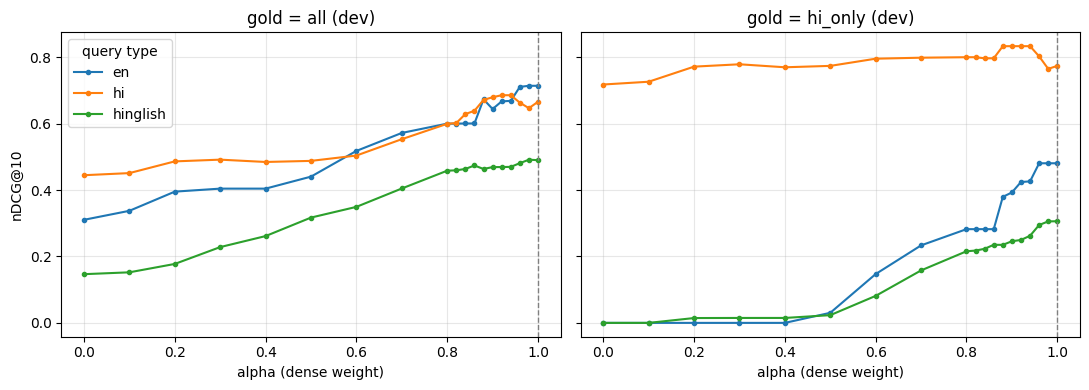

In [14]:
import matplotlib.pyplot as plt

ALPHAS = sorted(set(np.round(np.r_[np.arange(0, 0.8, 0.1), np.arange(0.8, 1.0001, 0.02)], 2)))
cache = {r.qid: (sparse_scores_sw(r.query), dense_scores(r.query)) for r in eval_queries.itertuples()}

rows = []
for r in eval_queries.itertuples():
    s_sp, s_de = cache[r.qid]
    for a in ALPHAS:
        ranked = weighted_fuse(s_sp, s_de, a)
        for mode, gsets in GOLD_SETS.items():
            if gsets[r.qid]:
                m = metrics_for(ranked, gsets[r.qid])
                rows.append({"alpha": a, "gold_mode": mode, "lang_type": r.lang_type, "split": r.split,
                             "ndcg@10": m["ndcg@10"], "hit@1": m["hit@1"]})
sweep = pd.DataFrame(rows)
sweep.to_csv(f"{RESULTS_DIR}/alpha_sweep_v2.csv", index=False)

dev = sweep[(sweep["split"] == "dev") & (sweep.gold_mode == "all")]
best_alpha = float(dev.groupby("alpha")["ndcg@10"].mean().idxmax())
print("Best alpha on dev (gold=all, mean nDCG@10):", best_alpha)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, mode in zip(axes, ["all", "hi_only"]):
    d = sweep[(sweep.gold_mode == mode) & (sweep["split"] == "dev")]
    for lt, g in d.groupby("lang_type"):
        g = g.groupby("alpha")["ndcg@10"].mean()
        ax.plot(g.index, g.values, marker="o", ms=3, label=lt)
    ax.axvline(best_alpha, ls="--", c="gray", lw=1)
    ax.set_title(f"gold = {mode} (dev)"); ax.set_xlabel("alpha (dense weight)"); ax.grid(alpha=.3)
axes[0].set_ylabel("nDCG@10"); axes[0].legend(title="query type")
plt.tight_layout(); plt.savefig(f"{RESULTS_DIR}/alpha_sweep_v2.png", dpi=200); plt.show()

In [ ]:
# Evaluate the dev-tuned alpha on the TEST split only
tuned_name = f"hybrid weighted (alpha={best_alpha}, dev-tuned)"
test_q = eval_queries[eval_queries["split"] == "test"]
if len(test_q):
    tuned = evaluate(tuned_name, make_weighted(best_alpha), "none", queries_df=test_q)
    comp = pd.concat([results[(results["split"] == "test") & (results["transform"] == "none")], tuned])
    print("TEST split, gold = hi_only, nDCG@10")
    display(comp[comp.gold_mode == "hi_only"].pivot_table(index="method", columns="lang_type", values="ndcg@10").round(3))
    print("TEST split, gold = all, nDCG@10")
    display(comp[comp.gold_mode == "all"].pivot_table(index="method", columns="lang_type", values="ndcg@10").round(3))
else:
    print("No test groups yet. Add more query groups.")

## 9. Tokenization check (RQ1 mechanism)

In [ ]:
tok = model.tokenizer
frag = eval_queries.copy()
frag["n_tokens"] = frag["query"].map(lambda q: len(tok.tokenize(q)))
frag["tokens_per_word"] = (frag.n_tokens / frag["query"].map(lambda q: len(q.split()))).round(2)
display(frag.groupby(["lang_type", "variant"])[["n_tokens", "tokens_per_word"]].mean().round(2))

first = frag.group_id.iloc[0]
for r in frag[frag.group_id == first].itertuples():
    print(f"{r.lang_type:9s} {r.variant:11s} {tok.tokenize(r.query)}")

## 10. Hand-off
- `results/per_query_results_v2.csv`: one row per (method, transform, query, gold_mode) with a `split` column
- `results/bootstrap_ci.csv`, `results/alpha_sweep_v2.csv/.png`
- To add a transform: define `def my_transform(q): return [q, transformed_q]`, put it in `TRANSFORMS`, and re-run the evaluation cells. Report on the **test** split and on **hi_only** gold.